# A320 — turbofan jet, and what changes versus the regional turboprop

Every other notebook here sizes a **propeller** aircraft, where the installed rating is
shaft power. This one sizes an **A320-200 class turbofan**, which is rated on **thrust** —
and that single difference propagates into the constraint diagram, the engine model, the
drag polar and the weight loop.

The notebook doubles as a validation: the design is compared against sourced Airbus and
EASA reference data (`validation/a320_reference.md`).

In [1]:
import sys, os
# reuse the baseline configs in examples/common.py (works whether the notebook is run
# from trunk/ or from trunk/notebooks/).
for _p in (os.path.join(os.getcwd(), 'examples'), os.path.join(os.getcwd(), '..', 'examples')):
    if os.path.isdir(_p):
        sys.path.insert(0, _p)
import matplotlib.pyplot as plt
import PhlyGreen as pg
from PhlyGreen import postprocess as pp
import numpy as np
from common import turbofan_config, traditional_config

## 1. Why a jet is a different sizing problem

`Performance.PoWTO` returns

$$P/W = g\left[\frac{q V C_D}{W/S} + \beta P_s\right] = \frac{D V + W\,\mathrm{ROC}}{m}$$

which is **thrust power** — there is no propulsive efficiency in it. So the requirement
physics is already propulsion-agnostic and $T/W = (P/W)/(gV)$ *exactly*. Nothing about the
aerodynamics changes for a jet.

What changes is the **rating the requirements are compared against**. That switch lives in
one method, `Powertrain.SizingDenominator`: it divides by the power lapse for a
propeller aircraft, and by $g\,V\,\lambda_T(h,M)$ for a turbofan.

This is more than a change of units. `FindDesignPoint` minimises the *largest* requirement
over wing loading, and each requirement is evaluated at its own speed — so the
minimum-installed-**power** point and the minimum-installed-**thrust** point are different
points, and can be set by different constraints.

In [2]:
config = turbofan_config()
print('configuration    :', config.configuration)
print('structural model :', config.aircraft_type, '(Class-'+config.weight_class+')')
print('drag polar       :', config.aerodynamics.analytic_polar['type'])
print('engine model     :', config.energy.eta_gas_turbine_model)
print()
print('design mission: {:.0f} nm, {:.0f} kg payload, {:.0f} nm alternate, {:.0f} min hold'
      .format(config.mission.range_mission, config.mission.payload_weight,
              config.mission.range_diversion, config.mission.time_loiter))

configuration    : Turbofan
structural model : NarrowBody (Class-I)
drag polar       : compressible
engine model     : Turbofan

design mission: 3000 nm, 14250 kg payload, 200 nm alternate, 30 min hold


## 2. The engine: one overall-efficiency node

The turboprop chain is `fuel → gas turbine → gearbox → propeller`. A turbofan has no
gearbox and no propeller, so the powertrain graph collapses to a **single node** carrying
the overall efficiency

$$\eta_o = \frac{F V}{\dot m_f\,\mathrm{LHV}}$$

This is not a simplification: because the graph normalises on propulsive power,
$P_f/P_p = 1/\eta_o$ is **exactly a TSFC closure**, since
$\mathrm{TSFC} = V/(\eta_o\,\mathrm{LHV})$. The two carry the same information, so fuel
burn, range and CO₂ all come out of the existing machinery unchanged.

$\eta_o$, TSFC and the thrust lapse all come from one pyCycle high-bypass turbofan sweep.

In [3]:
from PhlyGreen.Systems.Powertrain.turbofan_surrogate import TurbofanResponseSurface
s = TurbofanResponseSurface()
LHV, F00 = 43.0e6, config.energy.turbofan_design_thrust
print(f'map: {s.tag}')
print(f"{'condition':<30}{'eta_o':>8}{'TSFC':>16}{'lapse':>8}")
for label, alt, M, pc in [('take-off    SL     M 0.25', 0., 0.25, 1.00),
                          ('climb       10 kft M 0.55', 10000., 0.55, 0.90),
                          ('cruise      33 kft M 0.78', 33000., 0.78, 0.75),
                          ('cruise      35 kft M 0.78', 35000., 0.78, 0.85)]:
    lap = s.thrust_lapse(alt, M)
    eta, tsfc, _, _ = s.predict(F00, alt, M, pc*F00*lap)
    print(f'{label:<30}{eta:>8.3f}{tsfc*3600*9.80665:>11.3f} lb/lbf/h{lap:>8.3f}')
print()
print('A turboprop cruises at eta_o ~ 0.25-0.30 and much lower speed; the turbofan buys\n'
      'its efficiency back through flight speed, not through propeller efficiency.')

map: CFM56-class HBTF
condition                        eta_o            TSFC   lapse
take-off    SL     M 0.25        0.160      0.429 lb/lbf/h   0.770
climb       10 kft M 0.55        0.269      0.552 lb/lbf/h   0.524
cruise      33 kft M 0.78        0.321      0.595 lb/lbf/h   0.322
cruise      35 kft M 0.78        0.310      0.612 lb/lbf/h   0.329

A turboprop cruises at eta_o ~ 0.25-0.30 and much lower speed; the turbofan buys
its efficiency back through flight speed, not through propeller efficiency.


## 3. The drag polar: wave drag the turboprop never sees

An ATR42 cruises at M 0.4, far below drag divergence, so a plain quadratic polar is fine.
A jet cruises near it, so the `compressible` polar adds a Korn drag-divergence Mach number
and Lock's fourth-power wave drag:

$$M_{dd} = \frac{\kappa}{\cos\Lambda} - \frac{t/c}{\cos^2\Lambda} - \frac{C_L}{10\cos^3\Lambda},\qquad C_{D,wave} = 20\,(M-M_{crit})^4$$

The plain quadratic polar has **no wave drag at all**, and the legacy `Cd0` bump is flat
below M 0.8 and then steps *down* — neither can size a transonic aircraft.

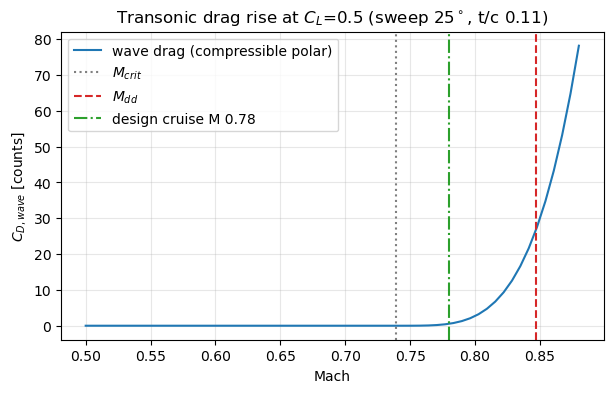

In [4]:
aero = pg.build_aircraft()
aero.configure(config, design=False)
a = aero.aerodynamics
M = np.linspace(0.5, 0.88, 60)
cl = 0.5
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(M, 1e4*np.asarray(a.Cd_wave(cl, M)), label='wave drag (compressible polar)')
ax.axvline(float(a.MachCrit(cl)), ls=':',  color='tab:grey', label='$M_{crit}$')
ax.axvline(float(a.MachDD(cl)),   ls='--', color='tab:red',  label='$M_{dd}$')
ax.axvline(0.78, ls='-.', color='tab:green', label='design cruise M 0.78')
ax.set_xlabel('Mach'); ax.set_ylabel('$C_{D,wave}$ [counts]')
ax.set_title(f'Transonic drag rise at $C_L$={cl} (sweep {a.sweep:.0f}$^\\circ$, t/c {a.tc})')
ax.grid(alpha=0.3); ax.legend(); plt.show()

## 3b. What the engine model actually looks like

Before flying it, it is worth seeing the response surface itself. Four views, each
showing something a constant-efficiency turboprop chain cannot represent:

* **$\eta_o$ against thrust fraction** — efficiency falls away at part throttle, and the
  whole curve shifts up with altitude because the cycle runs cooler and the flight speed
  is higher.
* **TSFC against Mach** — it *rises* with speed even though $\eta_o$ improves, because
  $\mathrm{TSFC} = V/(\eta_o\,\mathrm{LHV})$ and $V$ grows faster than $\eta_o$ does.
* **Thrust lapse** — this is the Mach dependence a turboshaft power lapse has no way to
  express, and it is fitted from the deck rather than assumed.
* **Air flow** — total through the inlet, and the core flow the combustor actually sees;
  the gap between them is the bypass stream.
* **Bypass ratio** — in this deck BPR is an off-design *balance* variable, solved against
  the bypass-nozzle throat area rather than held at its design value. That is why total
  inlet flow has to be read from the cycle directly: it is **not** the core flow times a
  fixed $(1+BPR)$. A turboprop has no analogue of any of this.

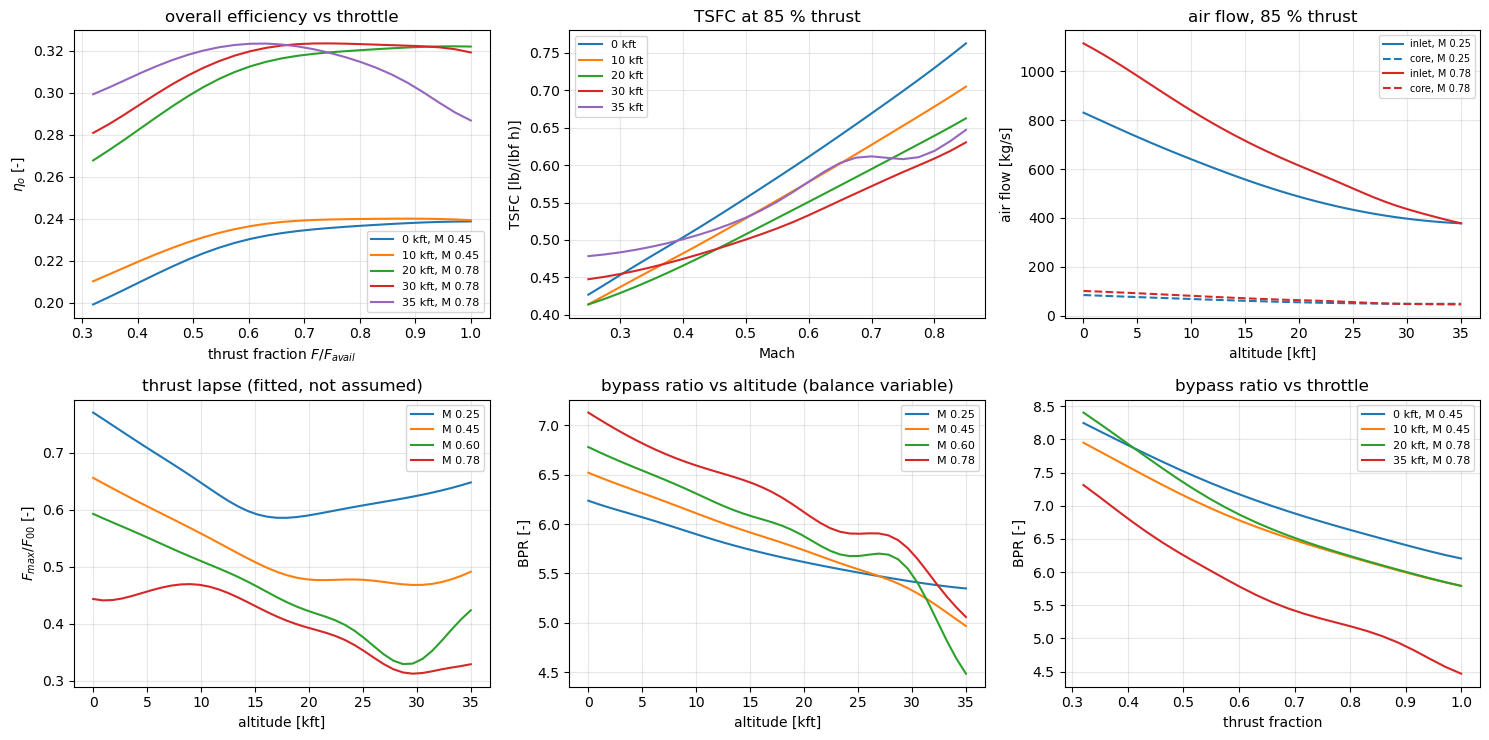

Total inlet flow and core (post-bypass-split, post-bleed) flow are both taken
from the pyCycle deck, scaled from the reference engine by installed thrust.
They are NOT related by a fixed (1+BPR): bypass ratio is an off-design balance
variable here, solved against the bypass-nozzle throat area, so it moves across
the flight envelope -- see the BPR panel in section 3b.


In [5]:
from PhlyGreen.Systems.Powertrain.turbofan_surrogate import TurbofanResponseSurface
s = TurbofanResponseSurface()
F00 = config.energy.turbofan_design_thrust
IMP = 3600 * 9.80665     # kg/(N s) -> lb/(lbf h)
fig, ax = plt.subplots(2, 3, figsize=(15, 7.5))

pcs = np.linspace(0.32, 1.0, 25)
for alt in (0., 10000., 20000., 30000., 35000.):
    M = 0.78 if alt >= 20000 else 0.45
    lap = s.thrust_lapse(alt, M)
    eta = [s.predict(F00, alt, M, pc*F00*lap)[0] for pc in pcs]
    ax[0,0].plot(pcs, eta, label=f'{alt/1000:.0f} kft, M {M:.2f}')
ax[0,0].set_xlabel('thrust fraction $F/F_{avail}$'); ax[0,0].set_ylabel(r'$\eta_o$ [-]')
ax[0,0].set_title('overall efficiency vs throttle'); ax[0,0].legend(fontsize=8)

machs = np.linspace(0.25, 0.85, 25)
for alt in (0., 10000., 20000., 30000., 35000.):
    y = []
    for M in machs:
        lap = s.thrust_lapse(alt, M)
        y.append(s.predict(F00, alt, M, 0.85*F00*lap)[1]*IMP)
    ax[0,1].plot(machs, y, label=f'{alt/1000:.0f} kft')
ax[0,1].set_xlabel('Mach'); ax[0,1].set_ylabel('TSFC [lb/(lbf h)]')
ax[0,1].set_title('TSFC at 85 % thrust'); ax[0,1].legend(fontsize=8)

alts = np.linspace(0., 35000., 40)
for M in (0.25, 0.45, 0.60, 0.78):
    ax[1,0].plot(alts/1000, [s.thrust_lapse(a, M) for a in alts], label=f'M {M:.2f}')
ax[1,0].set_xlabel('altitude [kft]'); ax[1,0].set_ylabel(r'$F_{max}/F_{00}$ [-]')
ax[1,0].set_title('thrust lapse (fitted, not assumed)'); ax[1,0].legend(fontsize=8)

for M, c in ((0.25,'tab:blue'), (0.78,'tab:red')):
    ax[0,2].plot(alts/1000, [s.inlet_air_flow(F00, a, M, 0.85) for a in alts],
                 color=c, label=f'inlet, M {M:.2f}')
    ax[0,2].plot(alts/1000, [s.core_air_flow(F00, a, M, 0.85) for a in alts],
                 color=c, ls='--', label=f'core, M {M:.2f}')
ax[0,2].set_xlabel('altitude [kft]'); ax[0,2].set_ylabel('air flow [kg/s]')
ax[0,2].set_title('air flow, 85 % thrust'); ax[0,2].legend(fontsize=7)

for M in (0.25, 0.45, 0.60, 0.78):
    ax[1,1].plot(alts/1000, [s.bypass_ratio(a, M, 0.85) for a in alts], label=f'M {M:.2f}')
ax[1,1].set_xlabel('altitude [kft]'); ax[1,1].set_ylabel('BPR [-]')
ax[1,1].set_title('bypass ratio vs altitude (balance variable)'); ax[1,1].legend(fontsize=8)

for alt in (0., 10000., 20000., 35000.):
    Mb = 0.78 if alt >= 20000 else 0.45
    ax[1,2].plot(pcs, [s.bypass_ratio(alt, Mb, pc) for pc in pcs],
                 label=f'{alt/1000:.0f} kft, M {Mb:.2f}')
ax[1,2].set_xlabel('thrust fraction'); ax[1,2].set_ylabel('BPR [-]')
ax[1,2].set_title('bypass ratio vs throttle'); ax[1,2].legend(fontsize=8)
for a in ax.ravel(): a.grid(alpha=0.3)
fig.tight_layout(); plt.show()
print('Total inlet flow and core (post-bypass-split, post-bleed) flow are both taken')
print('from the pyCycle deck, scaled from the reference engine by installed thrust.')
print('They are NOT related by a fixed (1+BPR): bypass ratio is an off-design balance')
print('variable here, solved against the bypass-nozzle throat area, so it moves across')
print('the flight envelope -- see the BPR panel in section 3b.')

## 4. Size it

The constraint diagram is now drawn in **T/W** rather than P/W — `plot_constraint_diagram`
switches the axis automatically for a `Turbofan`.

In [6]:
aircraft = pg.build_aircraft()
aircraft.configure(config)
r = aircraft.results()
print(f'take-off weight : {r.WTO:9.0f} kg')
print(f'empty weight    : {r.empty_weight:9.0f} kg')
print(f'block fuel      : {aircraft.weight.Wf + aircraft.weight.final_reserve:9.0f} kg')
print(f'wing area       : {aircraft.WingSurface:9.1f} m^2')
print(f'design T/W      : {r.DesignTW:9.4f} [-]')
print(f'design W/S      : {aircraft.DesignWTOoS/9.81:9.1f} kg/m^2')
print(f'SLS thrust      : {r.engineRating/1000:9.1f} kN  ({r.engineRating_units})')
print(f'mean TSFC       : {r.mean_TSFC*3600*9.80665:9.3f} lb/(lbf h)')

take-off weight :     79186 kg
empty weight    :     42891 kg
block fuel      :     22046 kg
wing area       :     171.1 m^2
design T/W      :    0.2523 [-]
design W/S      :     462.9 kg/m^2
SLS thrust      :     250.1 kN  (N)
mean TSFC       :     0.590 lb/(lbf h)


/Users/riccardo/Distributions/PhlyGreen/trunk/PhlyGreen/Systems/Powertrain/Powertrain.py:612: RuntimeWarning: turbofan nominal thrust is undersized: the design needs 250.1 kN SLS (mission peak) but the map was read against a nominal 240.2 kN. Raise 'Turbofan Design Thrust' and re-run so the engine is read at the right thrust fractions.
  warnings.warn(


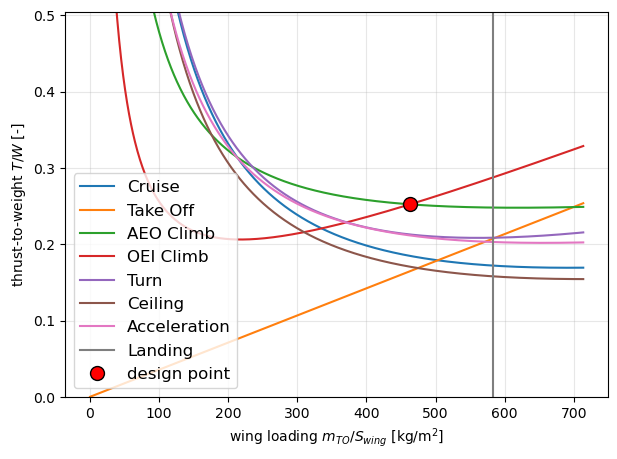

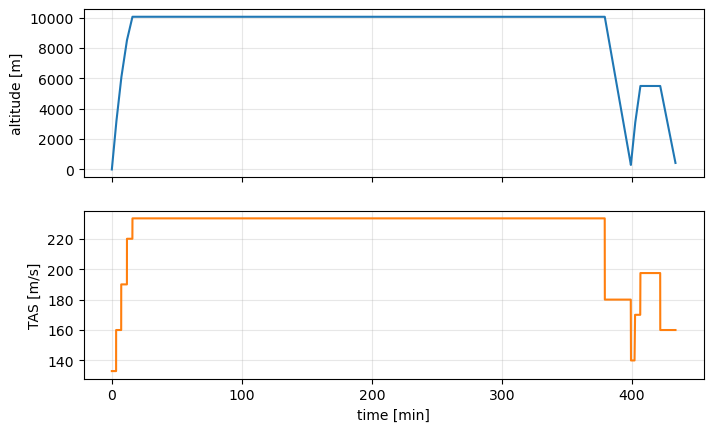

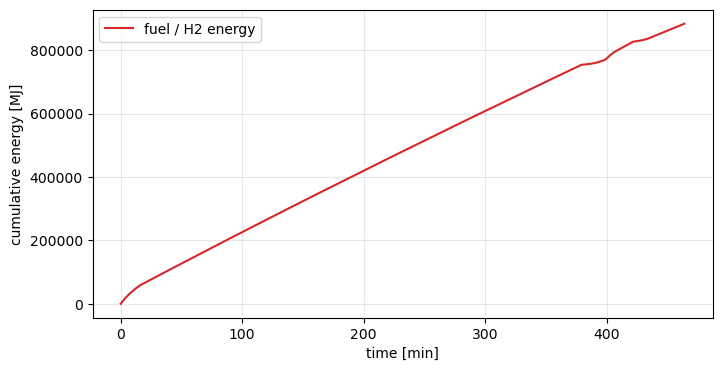

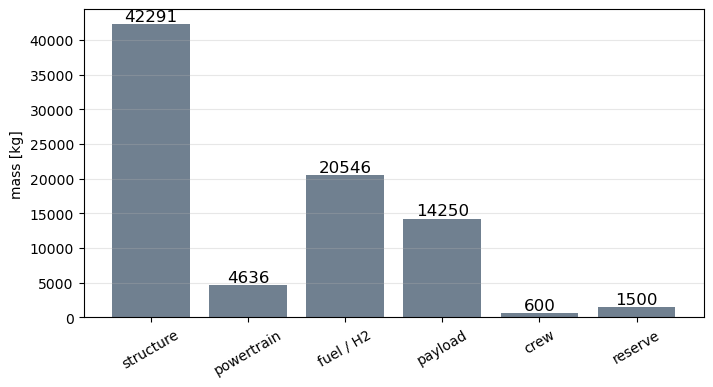

In [7]:
# Every outcome, including the time-resolved ones, via the generic post-processing helpers.
pp.plot_constraint_diagram(aircraft); plt.show()
pp.plot_mission_profile(aircraft);    plt.show()
pp.plot_energy_timeseries(aircraft);  plt.show()
pp.plot_mass_breakdown(aircraft);     plt.show()


## 4b. The engine along the mission

`postprocess.turbofan_timeseries` recovers the engine-level history from the converged
design — the thrust from the same `PoWTO` the mission integrated, the fuel flow from the
same `PRatio[0]` that closed the weight loop. These are the design, not a re-modelling of
it, and the integrated fuel below reproduces the weight loop's own answer to ~0.01 %.

Watch the step at top of climb: thrust drops by a factor of four between the climb and the
cruise, while TSFC *rises* — the engine is far more efficient per unit of thrust up there,
but each newton is bought at a higher speed.

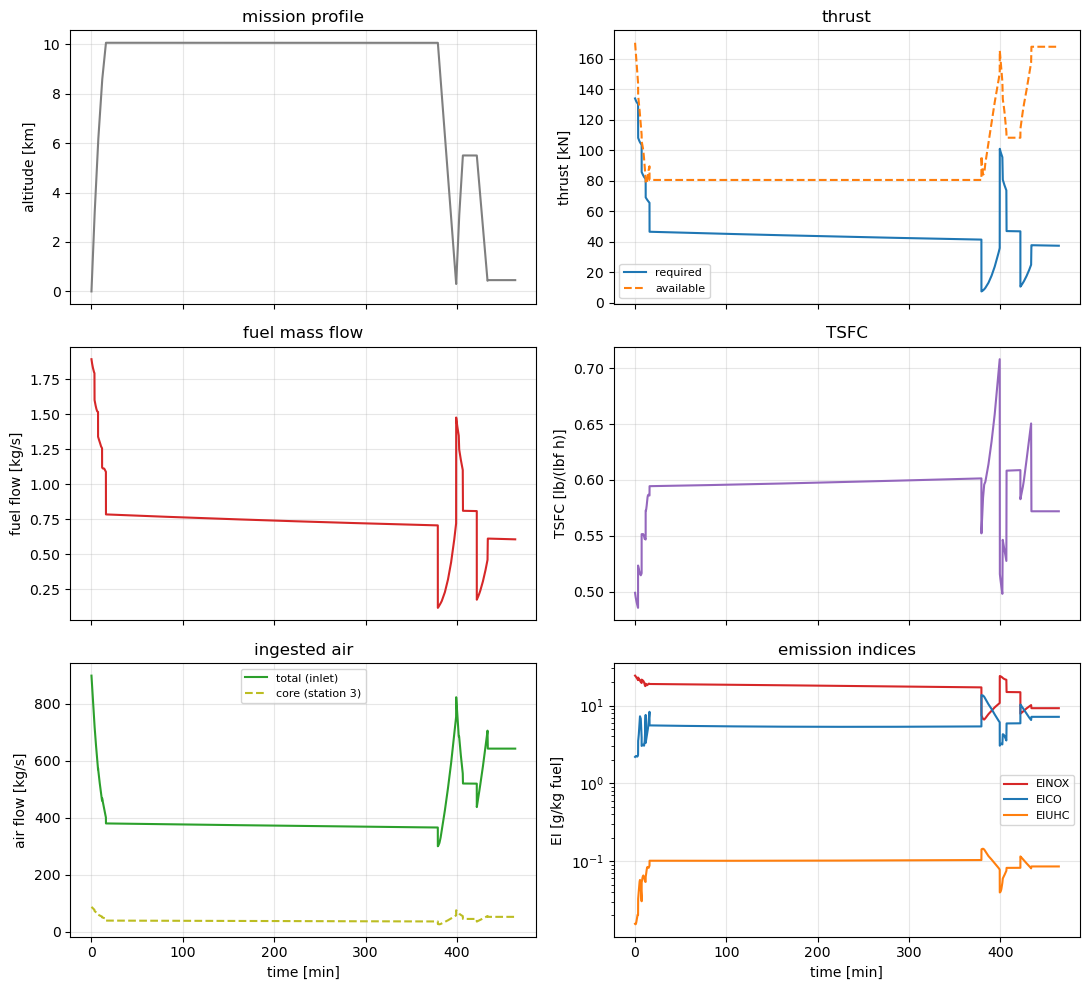

In [8]:
ts = pp.turbofan_timeseries(aircraft)
tmin = ts['time'] / 60.0
fig, ax = plt.subplots(3, 2, figsize=(11, 10), sharex=True)
ax[0,0].plot(tmin, ts['altitude']/1000, color='tab:grey')
ax[0,0].set_ylabel('altitude [km]'); ax[0,0].set_title('mission profile')
ax[0,1].plot(tmin, ts['thrust']/1e3, label='required')
ax[0,1].plot(tmin, ts['thrust_available']/1e3, ls='--', label='available')
ax[0,1].set_ylabel('thrust [kN]'); ax[0,1].set_title('thrust'); ax[0,1].legend(fontsize=8)
ax[1,0].plot(tmin, ts['fuel_flow'], color='tab:red')
ax[1,0].set_ylabel('fuel flow [kg/s]'); ax[1,0].set_title('fuel mass flow')
ax[1,1].plot(tmin, ts['tsfc']*3600*9.80665, color='tab:purple')
ax[1,1].set_ylabel('TSFC [lb/(lbf h)]'); ax[1,1].set_title('TSFC')
if 'inlet_air_flow' in ts:
    ax[2,0].plot(tmin, ts['inlet_air_flow'], color='tab:green', label='total (inlet)')
if 'core_air_flow' in ts:
    ax[2,0].plot(tmin, ts['core_air_flow'], ls='--', color='tab:olive',
                 label='core (station 3)')
ax[2,0].legend(fontsize=8)
ax[2,0].set_ylabel('air flow [kg/s]'); ax[2,0].set_title('ingested air')
ax[2,0].set_xlabel('time [min]')
for k, c in (('EINOX','tab:red'), ('EICO','tab:blue'), ('EIUHC','tab:orange')):
    if k in ts: ax[2,1].plot(tmin, ts[k], color=c, label=k)
ax[2,1].set_yscale('log'); ax[2,1].set_ylabel('EI [g/kg fuel]')
ax[2,1].set_title('emission indices'); ax[2,1].set_xlabel('time [min]')
ax[2,1].legend(fontsize=8)
for a in ax.ravel(): a.grid(alpha=0.3)
fig.tight_layout(); plt.show()

In [9]:
import numpy as np
print(f"mission duration      : {ts['time'][-1]/3600:8.2f} h")
print(f"fuel, integrated here : {np.trapezoid(ts['fuel_flow'], ts['time']):8.0f} kg")
print(f"fuel, weight loop     : {aircraft.weight.Wf:8.0f} kg   <- same number, two routes")
print()
for k in ('NOX', 'CO', 'UHC'):
    if k + '_kg' in ts:
        print(f'{k:<4} emitted          : {ts[k+chr(95)+chr(107)+chr(103)][-1]:8.1f} kg')

mission duration      :     7.73 h
fuel, integrated here :    20549 kg
fuel, weight loop     :    20546 kg   <- same number, two routes

NOX  emitted          :    359.3 kg
CO   emitted          :    111.8 kg
UHC  emitted          :      2.0 kg


## 5. What sizes the engine

A thrust-rated engine has three candidate sizing cases, and they are compared *after*
being referred back to sea level through the thrust lapse — available thrust falls with
both altitude and Mach, so the point that stresses the engine hardest is the one with the
largest $F/\lambda_T$, not the largest raw thrust.

For a transport that is usually **top of climb**, which is the classic result. The
turboprop equivalent is `report_class_ii_sizing()` in notebook 02.

In [10]:
rep = aircraft.powertrain.report_turbofan_sizing(warn=False)
for k, v in sorted(rep['cases'].items(), key=lambda kv: -kv[1]):
    mark = '  <-- sizing' if k == rep['sizing_case'] else ''
    print(f'{k:<22}{v/1000:8.1f} kN SLS{mark}')
print()
print(f"nominal thrust the map was read against: {rep['nominal']/1000:.1f} kN")
print(f"ratio required/nominal                : {rep['nominal_ratio']:.3f}")

mission peak             250.1 kN SLS  <-- sizing
constraint diagram       196.0 kN SLS
take-off / OEI           196.0 kN SLS

nominal thrust the map was read against: 240.2 kN
ratio required/nominal                : 1.041


## 6. Validation against the real A320

Reference data is sourced and cited in `validation/a320_reference.md`: MTOW, MZFW and the
engine thrust rating are **certification** data (Airbus ACAP, EASA TCDS); wing area and OEW
are secondary-source values and labelled as such.

Two design points are worth comparing. The default one minimises **installed thrust**. But
a narrow-body is sized by its **approach speed**: within the landing-field cap on wing
loading, a smaller wing is lighter and has less drag, so take-off weight keeps falling
right up to the wall. Minimum installed thrust is not minimum take-off weight.

In [11]:
import importlib.util, os
_v = os.path.join('validation', 'a320_reference.py')
if not os.path.exists(_v): _v = os.path.join('..', 'validation', 'a320_reference.py')
spec = importlib.util.spec_from_file_location('a320ref', _v)
a320 = importlib.util.module_from_spec(spec); spec.loader.exec_module(a320)
wall = a320.landing_limited_wing_loading()
print(f'landing-field wing-loading wall: {wall:.1f} kg/m^2')
a320.compare(aircraft, 'A) default - minimum installed thrust')
ac_land = a320._design(wall)
a320.compare(ac_land, f'B) landing-limited (W/S = {wall:.1f} kg/m^2)')

landing-field wing-loading wall: 582.6 kg/m^2

A) default - minimum installed thrust
  quantity             reference   PhlyGreen     delta      source
  MTOW                   78000.0     79186.4      1.5%    kg  primary
  OEW                    42600.0     42890.7      0.7%    kg  secondary
  wing_area                122.6       171.1     39.5% !  m2  secondary
  SLS_thrust_total         240.2       250.1      4.1%    kN  primary
  design W/S               636.2       462.9                kg/m2
  design T/W               0.314       0.252    -19.6%      derived from primary
  block fuel 22046 kg, mean TSFC 0.590 lb/(lbf h)

B) landing-limited (W/S = 582.6 kg/m^2)
  quantity             reference   PhlyGreen     delta      source
  MTOW                   78000.0     74673.8     -4.3%    kg  primary
  OEW                    42600.0     40914.5     -4.0%    kg  secondary
  wing_area                122.6       128.2      4.5%    m2  secondary
  SLS_thrust_total         240.2       233.8 

{'MTOW': 74673.77774576558,
 'OEW': 40914.504378297934,
 'wing_area': 128.17004405259817,
 'SLS_thrust_total': 233.8201061009803}

The wing-loading sweep below is the *evidence* for that claim rather than an assertion of
it: take-off weight falls monotonically with wing loading until the landing wall stops it.

/Users/riccardo/Distributions/PhlyGreen/trunk/PhlyGreen/Systems/Powertrain/Powertrain.py:612: RuntimeWarning: turbofan nominal thrust is undersized: the design needs 259.6 kN SLS (mission peak) but the map was read against a nominal 240.2 kN. Raise 'Turbofan Design Thrust' and re-run so the engine is read at the right thrust fractions.
  warnings.warn(
/Users/riccardo/Distributions/PhlyGreen/trunk/PhlyGreen/Systems/Powertrain/Powertrain.py:612: RuntimeWarning: turbofan nominal thrust is undersized: the design needs 252.6 kN SLS (mission peak) but the map was read against a nominal 240.2 kN. Raise 'Turbofan Design Thrust' and re-run so the engine is read at the right thrust fractions.
  warnings.warn(
/Users/riccardo/Distributions/PhlyGreen/trunk/PhlyGreen/Systems/Powertrain/Powertrain.py:612: RuntimeWarning: turbofan nominal thrust is undersized: the design needs 247.5 kN SLS (mission peak) but the map was read against a nominal 240.2 kN. Raise 'Turbofan Design Thrust' and re-run so th

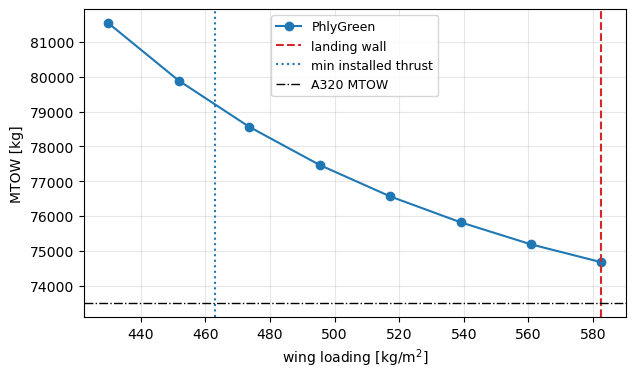

In [12]:
wall, sweep = a320.wing_loading_sweep()
ws = [p[0] for p in sweep]; mt = [p[1] for p in sweep]
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(ws, mt, 'o-', label='PhlyGreen')
ax.axvline(wall, color='tab:red', ls='--', label='landing wall')
ax.axvline(aircraft.DesignWTOoS/9.81, color='tab:blue', ls=':', label='min installed thrust')
ax.axhline(73500, color='k', ls='-.', lw=1, label='A320 MTOW')
ax.set_xlabel('wing loading [kg/m$^2$]'); ax.set_ylabel('MTOW [kg]')
ax.grid(alpha=0.3); ax.legend(fontsize=9); plt.show()

## 6b. Payload-range

The payload-range diagram is the clearest single picture of what an airliner can do, and
it needs something PhlyGreen does not normally do: an **off-design** calculation. The
sizing loop always re-sizes the aircraft, so here the empty weight and the wing are held
at the values the design converged on and only the fuel and take-off weight are solved
for. Every point below is therefore the *same* aircraft flown differently.

The curve has two legs:

* a **flat leg** at the design payload. Out to the design range the aircraft is not
  weight-limited — it simply carries less fuel for a shorter trip — so payload is
  constant and range is free.
* a **descending leg** beyond it. Take-off weight is now pinned at MTOW, so every extra
  kilogram of fuel has to be paid for with a kilogram of payload.

The corner between the two **is** the design mission, and that is the check: the aircraft
was sized to carry 14 250 kg over 3000 nm, so 3000 nm is exactly where it runs out of
take-off weight. Using the aircraft's own converged MTOW rather than the reference value
is what makes that come out right.

A real aircraft has a third limit — full tanks — which PhlyGreen does not model for
kerosene. The A320's usable capacity is marked below for scale.

*(This cell runs a few hundred mission integrations and takes a couple of minutes.)*

In [13]:
oew_sized = ac_land.results().empty_weight
mtow_own = ac_land.weight.WTO          # the aircraft's OWN converged take-off weight
design_payload = config.mission.payload_weight
pts, corner = a320.payload_range(oew_sized, mtow_own, wall, design_payload)
print(f'OEW {oew_sized:8.0f} kg    MTOW {mtow_own:8.0f} kg')
print(f'corner of the diagram : {corner[0]:6.0f} nm at {corner[1]:6.0f} kg')
print(f'design mission        : {config.mission.range_mission:6.0f} nm at {design_payload:6.0f} kg\n')
for R, P in pts:
    print(f'   {R:7.0f} nm   {P:8.0f} kg')

OEW    40915 kg    MTOW    74674 kg
corner of the diagram :   3001 nm at  14250 kg
design mission        :   3000 nm at  14250 kg

         0 nm      14250 kg
      3001 nm      14250 kg
      3690 nm      11044 kg
      4399 nm       7838 kg
      5127 nm       4631 kg
      5874 nm       1425 kg


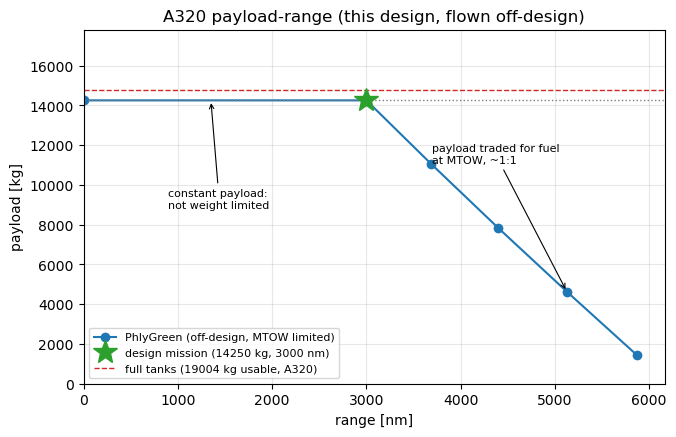

The corner sits on the design mission because the aircraft was sized for it.
Below the red line the real A320 would be out of tank volume; PhlyGreen has no
kerosene tank model, so the descending leg continues on weight alone.


In [14]:
max_fuel = 24209 * 0.785   # ACAP usable volume [l] x Jet-A density [kg/l]
R = [p[0] for p in pts]; P = [p[1] for p in pts]
fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(R, P, 'o-', color='tab:blue', label='PhlyGreen (off-design, MTOW limited)')
ax.plot([corner[0]], [corner[1]], '*', ms=18, color='tab:green', zorder=5,
        label=f'design mission ({design_payload:.0f} kg, {config.mission.range_mission:.0f} nm)')
ax.axhline(design_payload, color='tab:grey', ls=':', lw=1)
# where full tanks would cap it: the payload that leaves exactly max_fuel at MTOW
pl_fuel_lim = mtow_own - oew_sized - max_fuel
ax.axhline(pl_fuel_lim, color='tab:red', ls='--', lw=1,
           label=f'full tanks ({max_fuel:.0f} kg usable, A320)')
ax.annotate('constant payload:\nnot weight limited', xy=(corner[0]*0.45, design_payload),
            xytext=(corner[0]*0.30, design_payload*0.62), fontsize=8,
            arrowprops=dict(arrowstyle='->', lw=0.8))
ax.annotate('payload traded for fuel\nat MTOW, ~1:1', xy=(R[-2], P[-2]),
            xytext=(R[-2]*0.72, P[-2]*2.4), fontsize=8,
            arrowprops=dict(arrowstyle='->', lw=0.8))
ax.set_xlabel('range [nm]'); ax.set_ylabel('payload [kg]')
ax.set_title('A320 payload-range (this design, flown off-design)')
ax.set_ylim(0, design_payload*1.25); ax.set_xlim(0, max(R)*1.05)
ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='lower left'); plt.show()
print('The corner sits on the design mission because the aircraft was sized for it.')
print('Below the red line the real A320 would be out of tank volume; PhlyGreen has no')
print('kerosene tank model, so the descending leg continues on weight alone.')

### Empty weight, and two stated limits

The Class-I empty-weight model used here is `'NarrowBody'`, a regression fitted to six
in-service narrow-body transports (A319/A320/A321, B737-700/-800/-900ER), each reproduced
within 2 %:

$$W_e/W_0 = 4.2747\,W_0^{-0.1844}$$

It is a fit to a **population of aircraft**, not a calibration to this design's answer, so
MTOW, wing area and installed thrust remain independent checks. Being an *empty*-weight
fraction it already contains the installed engines, so the powertrain mass is not added on
top of it (`avoid_powertrain_double_count`). The textbook Raymer jet fraction, by contrast,
gives 0.495 at 78 t against ~0.546 for an A320-200 and is not used here.

Two limits worth stating:

* **FLOPS Class-II is rejected for turbofans** — its component set has no engine or pylon
  mass and always adds a propeller. The component-scaler calibration used for turboprop
  validations is not available here, and no mass breakdown below Class-I is claimed.
* The engine map is validated to **35 000 ft**; queries above it are clipped, which is
  *optimistic on available thrust*. The mission cruises at FL330 with the ceiling
  requirement at FL350, both inside the box.

## 7. Emissions: a jet burns differently

The emission *index* depends on the combustor operating point, so it is engine-size
independent but **not** engine-class independent. A turbofan runs a hotter, richer
combustor than a turboprop (FAR 0.015–0.029 against 0.009–0.017), and the table below
shows the consequence: at high thrust the turbofan index is the larger of the two, while
at low load the turboprop's is higher. Read the absolute values with care — the turboprop
map is certification-*anchored* (its level is asserted from ICAO), whereas the turbofan
map is unanchored and predicts its own level to about 26 % rms at the ICAO LTO points.

PhlyGreen therefore ships two emission-index maps and picks by configuration — the
turboprop one is keyed on a shaft-power fraction, the turbofan one on a **thrust** fraction.

In [15]:
from PhlyGreen.Systems.Powertrain.emissions_surrogate import (
    EmissionSurrogate, default_model_path)
tf = EmissionSurrogate(default_model_path('Turbofan'))
tp = EmissionSurrogate(default_model_path('Traditional'))
print(f"{'thrust/power fraction':<24}{'turbofan EINOx':>16}{'turboprop EINOx':>18}")
for pc in (0.30, 0.55, 0.85, 1.00):
    a = tf.predict_op(0.0, 0.25, pc)['EINOX']
    b = tp.predict_op(0.0, 0.25, pc)['EINOX']
    print(f'{pc:<24.2f}{a:>16.2f}{b:>18.2f}')

thrust/power fraction     turbofan EINOx   turboprop EINOx
0.30                                8.19             11.53
0.55                               21.19             11.99
0.85                               22.74             15.20
1.00                               21.16             17.96


Integrated over the mission, with the CO₂/H₂O/soot indices unchanged:

In [16]:
from PhlyGreen.config import ClimateImpactConfig
cfg2 = turbofan_config()
cfg2.climate_impact = ClimateImpactConfig(H=100, N=1.6e7, Y=30,
                                          einox_model='Surrogate',
                                          wtw_co2=8.30e-3, grid_co2=9.36e-2)
jet = pg.build_aircraft(); jet.configure(cfg2)
jet.MissionType = 'Continue'   # the EI surrogate integrates the continuous mission
jet.climateimpact.calculate_mission_emissions()
e = jet.climateimpact.mission_emissions
for k in ('co2', 'nox', 'co', 'uhc'):
    if k in e: print(f'{k.upper():<5}{e[k]:10.1f} kg per mission')

CO2     72342.2 kg per mission
NOX       359.2 kg per mission
CO        111.8 kg per mission
UHC         2.0 kg per mission


/Users/riccardo/Distributions/PhlyGreen/trunk/PhlyGreen/Systems/Powertrain/Powertrain.py:612: RuntimeWarning: turbofan nominal thrust is undersized: the design needs 250.1 kN SLS (mission peak) but the map was read against a nominal 240.2 kN. Raise 'Turbofan Design Thrust' and re-run so the engine is read at the right thrust fractions.
  warnings.warn(


## 8. Summary — what actually differs from the regional turboprop

| | ATR42 turboprop | A320 turbofan |
|---|---|---|
| installed rating | shaft power [W] | **thrust [N]** |
| constraint diagram | P/W vs W/S | **T/W vs W/S** |
| lapse | $(\rho/\rho_0)^{0.75}$, altitude only | **fitted $\lambda_T(h, M)$**, Mach too |
| powertrain graph | GT × gearbox × propeller | **one $\eta_o$ node** (= a TSFC closure) |
| drag polar | quadratic, no wave drag | **Korn/Lock compressible** |
| engine mass | peak shaft power / (W/kg) | **SLS thrust / (g · T/W)** |
| sizing case | take-off or climb peak power | **top of climb**, thrust referred to SLS |
| EI map | PW127, shaft-power fraction | **CFM56-class, thrust fraction** |
| weight class | Class-I or FLOPS Class-II | **Class-I only** (FLOPS has no engine mass) |

What does *not* change is the aerodynamic core: `PoWTO` was always thrust power, which is
why the same mission integrator, weight loop and climate model serve both aircraft.